In [2]:
from astropy.table import Table
import numpy as np

from astropy.coordinates import Angle
import astropy.units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from collections import Counter

In [3]:
catalog_dir = '/home/alab_student/Tim/Projects/Catalogs/'
outdir = "/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/"

In [4]:
Firm_MeV_Blazar_Catalog = Table.read(catalog_dir + 'Firm_MeV_Blazar_Catalog.fits')
print(len(Firm_MeV_Blazar_Catalog))
Cross_Match1 = Table.read(catalog_dir + 'crossmatch_SED_latest.fits')
MeV_Blazar_Catalog = Table.read(catalog_dir + 'MeV_Blazar_Catalog_v2.fits')
Cross_Match2 = Table.read(catalog_dir + 'cross_match_updated.fits')
LAC = Table.read(catalog_dir + 'Fermi_LAC_DR3.fits')
MeV_Blazar_Catalog_FINAL = Table.read(catalog_dir + 'MeV_Blazars_Catalog_FINAL.fits')

Fermi_Blazar_mask = [x in ['BLL','bll','FSRQ','fsrq','bcu'] for x in Cross_Match1['fermi_category_type']]
Swift_Blazar_mask = [x == 'Beamed AGN' for x  in Cross_Match1[Fermi_Blazar_mask]['bat_category_type']]

Firm_Matches_Old = Cross_Match1[Fermi_Blazar_mask][Swift_Blazar_mask]
print(len(Firm_Matches_Old))

115
96


In [52]:
#Firm_MeV_Blazar_Catalog.pprint_all()
for i in range(len(Firm_MeV_Blazar_Catalog)):
    Swift_Redshift = Firm_MeV_Blazar_Catalog['Swift Redshift'].tolist()[i]
    Fermi_Redshift = Firm_MeV_Blazar_Catalog['Fermi Redshift'].tolist()[i]
    
    if Swift_Redshift != None:
        Redshift = Swift_Redshift
    elif Swift_Redshift == None and Fermi_Redshift != None:
        Redshift = Fermi_Redshift
    else:
        Redshift = None
        
    print(f"{Firm_MeV_Blazar_Catalog['Fermi Counterpart Name'].tolist()[i]} & {Firm_MeV_Blazar_Catalog['Fermi Type'].tolist()[i]} & {Firm_MeV_Blazar_Catalog['Swift Counterpart Name'].tolist()[i]} & {Firm_MeV_Blazar_Catalog['Swift Type'].tolist()[i]} & {Redshift} & {Firm_MeV_Blazar_Catalog['SED Class'].tolist()[i]} \\\\")

1ES 0033+595 & bll & 1ES 0033+595 & BZB & 0.086 & HSP \\
1ES 0120+340 & bll & SHBL J012308.7+342049 & BZB & 0.272 & HSP \\
B3 0133+388 & bll & B3 0133+388 & BZB & None & HSP \\
TXS 0134+579 & bll & 2FHL J0138.2+5811 & Beamed AGN & None & HSP \\
1RXS J015658.6-530208 & bll & RBS 259 & Beamed AGN & None & HSP \\
PKS 0202-17 & fsrq & QSO B0202-172 & FSRQ & 1.7395 & LSP \\
TXS 0210+515 & bll & 2MASX J02141794+5144520 & BZG & 0.049 & HSP \\
S5 0212+73 & fsrq & [HB89] 0212+735 & BZQ & 2.367 & LSP \\
1ES 0229+200 & bll & QSO B0229+200 & BZG & 0.1396 & HSP \\
RBS 0351 & bll & BZB J0244-5819 & Beamed AGN & 0.2645 & HSP \\
4C +33.06 & bcu & 4C +33.06 & Beamed AGN & None & LSP \\
1RXS J032521.8-563543 & bll & 2MASX J03252346-5635443 & BZG & 0.0602 & HSP \\
TXS 0322+222 & fsrq & QSO J0325+2224 & FSRQ & 2.066 & LSP \\
1ES 0347-121 & bll & QSO B0347-121 & BZG & 0.18 & HSP \\
PKS 0352-686 & bll & PKS 0352-686 & BZB & 0.087 & HSP \\
NRAO 150 & fsrq & 4C +50.11 & BZQ & 1.52 & LSP \\
PKS 0402-362 & FSRQ

In [6]:
BAT_105m = Table.read(catalog_dir + 'BAT_105m_catalog_SED.fits')
print(Counter(BAT_105m['TYPE'].tolist()))

Counter({'Sy2': 310, 'Sy1': 161, 'Beamed AGN': 158, 'Sy1.9': 128, 'Unknown AGN': 114, 'Sy1.5': 111, 'LMXB': 109, 'HMXB': 108, 'Sy1.2': 96, 'CV': 75, 'U2': 55, 'U3': 38, 'U1': 36, 'Galaxy Cluster': 26, 'Pulsar': 25, 'star': 12, 'confused source': 10, 'Sy2 candidate': 10, 'Sy1.8': 9, 'XRB': 8, 'SNR': 7, 'LINER': 6, 'Nova': 6, 'Symbiotic star': 4, 'Sy1;broad-line AGN': 2, 'molecular cloud': 2, 'Compact group of galaxies': 1, 'Open star cluster': 1, 'Starburst galaxy': 1, 'Galactic Center': 1, 'Gamma-ray source': 1, 'GC': 1})


In [7]:
LAT_4FGL_DR2 = Table.read(catalog_dir + '4FGLDR2.fit')
print(Counter(LAT_4FGL_DR2['CLASS1'].tolist()))
print(len(LAT_4FGL_DR2))

Counter({'     ': 1667, 'bcu  ': 1382, 'bll  ': 1286, 'fsrq ': 701, 'PSR  ': 237, 'unk  ': 115, 'spp  ': 96, 'FSRQ ': 43, 'rdg  ': 38, 'psr  ': 34, 'glc  ': 30, 'SNR  ': 24, 'BLL  ': 22, 'snr  ': 19, 'PWN  ': 12, 'agn  ': 10, 'sbg  ': 8, 'bin  ': 8, 'HMB  ': 6, 'RDG  ': 6, 'pwn  ': 6, 'nlsy1': 5, 'css  ': 5, 'NLSY1': 4, 'gal  ': 3, 'SFR  ': 3, 'GAL  ': 2, 'sfr  ': 2, 'LMB  ': 2, 'BCU  ': 2, 'hmb  ': 2, 'ssrq ': 2, 'lmb  ': 2, 'AGN  ': 1, 'BIN  ': 1, 'sey  ': 1, 'NOV  ': 1})
5788


In [8]:
Firm_MeV_Blazar_Catalog[Firm_MeV_Blazar_Catalog['SED Class'] == 'ISP']

id,Match Flag,Fermi Counterpart Name,Swift Counterpart Name,Fermi Type,Swift Type,SED Class,Fermi RA,Fermi DEC,Swift RA,Swift DEC,Fermi Redshift,Swift Redshift,Fermi Photon Index,Fermi Photon Index Err,Swift Photon Index,Swift Photon Index Err,Log Swift Luminosity,Syn Peak Energy,Syn Peak Flux,Energy,Energy Flux,Energy Flux Err
,,,,,,,deg,deg,deg,deg,,,,,,,erg / s,MeV,MeV / (s cm2),MeV,MeV / (s cm2),MeV / (s cm2)
int64,bytes1,bytes23,bytes26,bytes4,bytes15,bytes4,float64,float64,float64,float64,bytes32,bytes32,float64,bytes32,float64,float64[2],bytes32,bytes32,bytes32,float64[16],float64[16],"float64[2,16]"
40,M,S5 0716+71,[HB89] 0716+714,BLL,Beamed AGN,ISP,110.48819732666016,71.34049987792969,110.5267,71.3241,0.12700000405311584,0.3,2.0652098655700684,0.004811827093362808,0.92,0.53 .. 1.28,45.72,6.131201887159258e-07,3.025064268451132e-08,0.016999999999999998 .. 316227.7660168379,1.12122821e-06 .. 1.9829525647386582e-06,5.27996453e-07 .. 4.4174018421023767e-07
50,M,RXC J0934.4-1721,2MASS J09343014-1721215,bll,Beamed AGN,ISP,143.6278076171875,-17.33880043029785,143.5966,-17.3388,0.2498999983072281,0.2499,1.9021245241165161,0.1390642374753952,3.11,2.36 .. 4.29,45.01,2.6094298803265764e-06,5.76436651762414e-10,0.016999999999999998 .. 316227.7660168379,3.07698222e-06 .. 5.316096088206295e-07,7.29133841e-07 .. 4.1923693141604313e-07


In [9]:
Cross_Match2.pprint_all()


 id flag legacy_flag    bat_name_counterpart    bat_category_type  fermi_name_counterpart fermi_category_type       separation             delta_sep        bat_pindex bat_pindex_errm bat_pindex_errp        bat_flux            bat_flux_errm          bat_flux_errp       bat_ra  bat_dec  fermi_pindex_PL  fermi_pindex_PL_err    fermi_flux   fermi_flux_err fermi_ra fermi_dec                   Energy                                    Energy_Flux                                    Energy_Flux_Err                 
                                                                                                                       deg                    deg                                                          erg / (s cm2)          erg / (s cm2)          erg / (s cm2)        deg      deg                                          erg / (s cm2)  erg / (s cm2)    deg       deg                       MeV                                     MeV / (s cm2)                                    MeV / 

In [10]:
Fermi_Blazar_mask2 = [x in ['BLL','bll','FSRQ','fsrq','bcu'] for x in Cross_Match2['fermi_category_type']]
Swift_Blazar_mask2 = [x in ['Beamed AGN', 'BZQ', 'BZB','FSRQ','BZG','BZQ/Lense'] for x  in Cross_Match2[Fermi_Blazar_mask2]['bat_category_type']]
Swift_Blazar_mask3 = [x in ['Beamed AGN', 'BZQ', 'BZB','FSRQ','BZG','BZQ/Lense'] for x  in Cross_Match2['bat_category_type']]

In [11]:
print(Counter(Cross_Match2[Fermi_Blazar_mask2]['bat_category_type']))
print(Counter(Cross_Match2[Swift_Blazar_mask3]['fermi_category_type']))

Counter({'BZQ': 44, 'Beamed AGN': 32, 'BZB': 22, 'FSRQ': 10, 'BZG': 6, 'Sy1': 4, 'Sy1.9': 2, 'Unknown': 2, 'Other AGN': 1, 'CV': 1, 'confused source': 1, 'Sy1.5': 1, 'BZQ/Lense': 1})
Counter({'fsrq': 41, 'bll': 36, 'FSRQ': 20, 'bcu': 11, 'BLL': 7, 'css': 2, 'nlsy1': 1})


In [12]:
Sep_Mask = [x <= 0.08 for x in Cross_Match2['separation']]
Id_Mask = [x >= 0.08 for x in Cross_Match2['separation']]

print(len(Cross_Match2[Sep_Mask]))
print(Counter(Cross_Match2[Sep_Mask]['fermi_category_type']))
print(Counter(Cross_Match2[Sep_Mask]['bat_category_type']))

print(len(Cross_Match2[Id_Mask]))
print(Counter(Cross_Match2[Id_Mask]['fermi_category_type']))
print(Counter(Cross_Match2[Id_Mask]['bat_category_type']))

163
Counter({'bll': 36, 'fsrq': 35, 'FSRQ': 18, 'bcu': 12, 'glc': 7, 'PSR': 7, 'BLL': 7, 'sbg': 4, 'rdg': 4, 'MSP': 4, 'HMB': 3, 'RDG': 3, 'unk': 3, 'snr': 2, 'LMB': 2, 'css': 2, 'hmb': 2, 'pwn': 2, 'psr': 2, 'nlsy1': 1, 'AGN': 1, 'PWN': 1, 'lmb': 1, 'NLSY1': 1, 'BIN': 1, 'sey': 1, 'agn': 1})
Counter({'BZQ': 38, 'Beamed AGN': 25, 'BZB': 21, 'LMXB': 16, 'Sy1': 14, 'FSRQ': 8, 'Pulsar': 7, 'BZG': 6, 'HMXB': 5, 'SNR': 4, 'Sy1.9': 4, 'Unknown': 3, 'Sy2': 3, 'CV': 2, 'Other AGN': 1, 'confused source': 1, 'Starburst galaxy': 1, 'XRB': 1, 'Sy1.5': 1, 'GC': 1, 'BZQ/Lense': 1})
26
Counter({'fsrq': 12, 'bll': 3, 'bcu': 2, 'rdg': 2, 'FSRQ': 2, 'PSR': 1, 'HMB': 1, 'unk': 1, 'snr': 1, 'GC': 1})
Counter({'BZQ': 9, 'Beamed AGN': 7, 'FSRQ': 2, 'Sy1.2': 1, 'Pulsar': 1, 'Sy1.8': 1, 'HMXB': 1, 'Unknown Star': 1, 'SNR': 1, 'Galactic Center': 1, 'BZB': 1})


In [13]:
print(Counter(Cross_Match2['fermi_category_type']))
print(Counter(Cross_Match2['bat_category_type']))

Firm_Matches_New = Cross_Match2[Fermi_Blazar_mask2][Swift_Blazar_mask2]
Firm_Matches_New.pprint_all()

Counter({'fsrq': 47, 'bll': 39, 'FSRQ': 20, 'bcu': 14, 'PSR': 8, 'glc': 7, 'BLL': 7, 'rdg': 6, 'HMB': 4, 'sbg': 4, 'MSP': 4, 'unk': 4, 'snr': 3, 'RDG': 3, 'LMB': 2, 'css': 2, 'hmb': 2, 'pwn': 2, 'psr': 2, 'nlsy1': 1, 'AGN': 1, 'PWN': 1, 'lmb': 1, 'NLSY1': 1, 'BIN': 1, 'sey': 1, 'agn': 1, 'GC': 1})
Counter({'BZQ': 47, 'Beamed AGN': 32, 'BZB': 22, 'LMXB': 16, 'Sy1': 14, 'FSRQ': 10, 'Pulsar': 8, 'BZG': 6, 'HMXB': 6, 'SNR': 5, 'Sy1.9': 4, 'Unknown': 3, 'Sy2': 3, 'CV': 2, 'Other AGN': 1, 'confused source': 1, 'Starburst galaxy': 1, 'XRB': 1, 'Sy1.5': 1, 'GC': 1, 'BZQ/Lense': 1, 'Sy1.2': 1, 'Sy1.8': 1, 'Unknown Star': 1, 'Galactic Center': 1})
 id flag legacy_flag    bat_name_counterpart    bat_category_type  fermi_name_counterpart fermi_category_type      separation             delta_sep        bat_pindex bat_pindex_errm bat_pindex_errp        bat_flux            bat_flux_errm          bat_flux_errp       bat_ra  bat_dec  fermi_pindex_PL  fermi_pindex_PL_err    fermi_flux   fermi_flux_err f

In [14]:
print(Counter(Firm_Matches_New['fermi_category_type']))
print(Counter(Firm_Matches_New['bat_category_type']))

Counter({'fsrq': 41, 'bll': 36, 'FSRQ': 20, 'bcu': 11, 'BLL': 7})
Counter({'BZQ': 44, 'Beamed AGN': 32, 'BZB': 22, 'FSRQ': 10, 'BZG': 6, 'BZQ/Lense': 1})


In [15]:
print(LAC.colnames)

['Source_Name', 'DataRelease', 'RAJ2000', 'DEJ2000', 'GLON', 'GLAT', 'Signif_Avg', 'Flux1000', 'Unc_Flux1000', 'Energy_Flux100', 'Unc_Energy_Flux100', 'SpectrumType', 'PL_Index', 'Unc_PL_Index', 'Pivot_Energy', 'LP_Index', 'Unc_LP_Index', 'LP_beta', 'Unc_LP_beta', 'Flags', 'CLASS', 'ASSOC1', 'ASSOC_PROB_BAY', 'ASSOC_PROB_LR', 'Counterpart_Catalog', 'RA_Counterpart', 'DEC_Counterpart', 'Unc_Counterpart', 'VLBI_Counterpart', 'Redshift', 'SED_class', 'HE_EPeak', 'Unc_HE_EPeak', 'HE_nuFnuPeak', 'Unc_HE_nuFnuPeak', 'nu_syn', 'nuFnu_syn', 'Variability_Index', 'Frac_Variability', 'Unc_Frac_Variability', 'Highest_energy']


In [16]:
LAC_mask = [x in Firm_Matches_New['fermi_name_counterpart'].tolist() for x in LAC['ASSOC1'].tolist()]
print(len(LAC[LAC_mask]))
LAC[LAC_mask].pprint_all()

print([x for x in Firm_Matches_New['fermi_name_counterpart'].tolist() if x not in LAC[LAC_mask]['ASSOC1'].tolist()])


113
   Source_Name    DataRelease RAJ2000  DEJ2000    GLON     GLAT   Signif_Avg   Flux1000   Unc_Flux1000 Energy_Flux100 Unc_Energy_Flux100    SpectrumType   PL_Index Unc_PL_Index Pivot_Energy LP_Index Unc_LP_Index LP_beta  Unc_LP_beta Flags CLASS          ASSOC1         ASSOC_PROB_BAY ASSOC_PROB_LR Counterpart_Catalog RA_Counterpart DEC_Counterpart Unc_Counterpart VLBI_Counterpart Redshift SED_class  HE_EPeak  Unc_HE_EPeak  HE_nuFnuPeak  Unc_HE_nuFnuPeak       nu_syn         nuFnu_syn    Variability_Index Frac_Variability Unc_Frac_Variability Highest_energy
                                deg      deg      deg      deg               ph / (s cm2) ph / (s cm2) erg / (s cm2)    erg / (s cm2)                                                MeV                                                                                                                                           deg             deg             deg                                              MeV         MeV      MeV / (s 

In [17]:
Firm_Matches_New.pprint_all()

 id flag legacy_flag    bat_name_counterpart    bat_category_type  fermi_name_counterpart fermi_category_type      separation             delta_sep        bat_pindex bat_pindex_errm bat_pindex_errp        bat_flux            bat_flux_errm          bat_flux_errp       bat_ra  bat_dec  fermi_pindex_PL  fermi_pindex_PL_err    fermi_flux   fermi_flux_err fermi_ra fermi_dec                   Energy                                    Energy_Flux                                    Energy_Flux_Err                
                                                                                                                      deg                    deg                                                          erg / (s cm2)          erg / (s cm2)          erg / (s cm2)        deg      deg                                          erg / (s cm2)  erg / (s cm2)    deg       deg                       MeV                                     MeV / (s cm2)                                    MeV / (s 

In [18]:
print([(x,y) for x,y in list(zip(Firm_Matches_New['fermi_name_counterpart'].tolist(), Firm_Matches_New['bat_name_counterpart'].tolist()))
    if x in Cross_Match1['fermi_name_counterpart'].tolist()
    and x not in Firm_Matches_Old['fermi_name_counterpart'].tolist()
])

[('PMN J1310-5552', 'IGR J13109-5552'), ('PKS 2331-240', 'PKS 2331-240')]


In [19]:
Cross_Match1.pprint_all()

 id Flag    bat_name_counterpart    bat_category_type  fermi_name_counterpart fermi_name_counterpart2 fermi_category_type     separation     bat_id bat_pindex  bat_pindex_errm    bat_pindex_errp          bat_flux            bat_flux_errm          bat_flux_errp       bat_ra bat_dec bat_redshift fermi_id  fermi_pindex_PL   fermi_pindex_PL_err       fermi_flux          fermi_flux_errm        fermi_flux_errp      fermi_var_index        fermi_ra           fermi_dec      match_with_1FLE match_4FGLand1FLE_IDmatch            Energy                    Energy_err                              Flux_err                                           Flux                           is_ul     
                                                                                                                                                                                                                                                                                                                              

In [20]:
MeV_Blazar_Catalog.pprint_all()

 id Match Flag  Fermi Counterpart Name   Swift Counterpart Name   Fermi Type    Swift Type   SED Class      Fermi RA           Fermi DEC      Swift RA Swift DEC    Fermi Redshift    Swift Redshift Fermi Photon Index Fermi Photon Index Err Swift Photon Index Swift Photon Index Err Log Swift Luminosity    Syn Peak Energy         Syn Peak Flux                        Energy                                    Energy Flux                                    Energy Flux Err                
                                                                                                              deg                 deg           deg       deg                                                                                                                                  erg / s                 MeV               MeV / (s cm2)                         MeV                                     MeV / (s cm2)                                    MeV / (s cm2)                 
--- ---------- -----------

In [21]:
Opt_Class = [x.lower() for x in Firm_MeV_Blazar_Catalog['Fermi Type'].tolist()]
SED_Class = Firm_MeV_Blazar_Catalog['SED Class'].tolist()
Classes = Counter(zip(Opt_Class, SED_Class))
print(Classes)

Counter({('fsrq', 'LSP'): 56, ('bll', 'HSP'): 34, ('bll', 'LSP'): 7, ('bcu', 'LSP'): 6, ('fsrq', 'None'): 5, ('bcu', 'HSP'): 4, ('bll', 'ISP'): 2, ('bcu', 'None'): 1})


In [22]:
Fermi_Name_Firm_Old = Firm_Matches_Old['fermi_name_counterpart'].tolist()
Fermi_Name_Firm = Firm_MeV_Blazar_Catalog['Fermi Counterpart Name'].tolist()

new_names = [x for x in Fermi_Name_Firm if x not in Fermi_Name_Firm_Old]
print(len(new_names))
print(new_names)

lost_name = [x for x in Fermi_Name_Firm_Old if x not in Fermi_Name_Firm]
print(lost_name)

20
['TXS 0134+579', 'PKS 0202-17', 'TXS 0322+222', 'PKS 0454-46', 'RX J0648.7+1516', '1ES 0647+250', 'PKS 0736+01', 'SUMSS J082627-640414', 'PMN J0957-1350', 'PMN J1310-5552', 'AP Librae', 'PG 1553+113', '4C +38.41', 'PKS 1824-582', 'PKS 2223+21', 'PKS 2331-240', '4C +06.41', 'OG 050', '4C +73.18', 'PMN J2010-2524']
['PKS 0524-460']


In [23]:
New_Matched_Blazars = Firm_MeV_Blazar_Catalog[[x in new_names for x in Firm_MeV_Blazar_Catalog['Fermi Counterpart Name']]]
print(Counter(zip(New_Matched_Blazars['Fermi Type'].tolist(), New_Matched_Blazars['SED Class'].tolist())))
print(Counter(New_Matched_Blazars['Fermi Type'].tolist()))
print(Counter(New_Matched_Blazars['SED Class'].tolist()))
New_Matched_Blazars.pprint_all()

Counter({('fsrq', 'LSP'): 7, ('bll', 'HSP'): 4, ('fsrq', 'None'): 3, ('FSRQ', 'LSP'): 2, ('bcu', 'HSP'): 1, ('bll', 'LSP'): 1, ('BLL', 'HSP'): 1, ('bcu', 'LSP'): 1})
Counter({'fsrq': 10, 'bll': 5, 'bcu': 2, 'FSRQ': 2, 'BLL': 1})
Counter({'LSP': 11, 'HSP': 6, 'None': 3})
 id Match Flag Fermi Counterpart Name  Swift Counterpart Name Fermi Type Swift Type SED Class      Fermi RA           Fermi DEC      Swift RA Swift DEC    Fermi Redshift   Swift Redshift Fermi Photon Index Fermi Photon Index Err Swift Photon Index Swift Photon Index Err Log Swift Luminosity    Syn Peak Energy         Syn Peak Flux                        Energy                                   Energy Flux                                   Energy Flux Err                
                                                                                                     deg                 deg           deg       deg                                                                                                          

In [24]:
RA = np.array(Firm_MeV_Blazar_Catalog['Fermi RA'].tolist())
DEC = np.array(Firm_MeV_Blazar_Catalog['Fermi DEC'].tolist())

coords = SkyCoord(ra=RA*u.deg, dec=DEC*u.deg, frame='icrs')
l = coords.galactic.l.deg
b = coords.galactic.b.deg

for i in range(len(Firm_MeV_Blazar_Catalog)):
    print(RA[i], DEC[i])

8.9822998046875 59.83340072631836
20.790599822998047 34.35380172729492
24.14229965209961 39.099998474121094
24.49570083618164 58.2494010925293
29.232799530029297 -53.030799865722656
31.263700485229492 -17.002199172973633
33.594600677490234 51.75699996948242
34.35329818725586 73.88040161132812
38.21390151977539 20.315900802612305
41.15760040283203 -58.325599670410156
46.137901306152344 33.82609939575195
51.379398345947266 -56.590999603271484
51.442100524902344 22.432600021362305
57.35390090942383 -11.994099617004395
58.273799896240234 -68.5281982421875
59.91579818725586 50.95899963378906
60.974998474121094 -36.08700180053711
61.41889953613281 -13.143799781799316
73.94629669189453 -46.28710174560547
76.99559783935547 67.62229919433594
82.73639678955078 13.540200233459473
84.70890045166016 -44.08620071411133
84.99520111083984 -28.65850067138672
87.62519836425781 -32.277099609375
88.90149688720703 39.78779983520508
98.9021987915039 -75.30460357666016
100.02130126953125 -12.895999908447266


In [25]:
Swift_Name_Firm_Old = Firm_Matches_Old['bat_name_counterpart'].tolist()
Swift_Name_Firm = Firm_MeV_Blazar_Catalog['Swift Counterpart Name'].tolist()

new_names = [x for x in Swift_Name_Firm if x not in Swift_Name_Firm_Old]
print(len(new_names))
print(new_names)

lost_name = [x for x in Swift_Name_Firm_Old if x not in Swift_Name_Firm]
print(lost_name)

20
['2FHL J0138.2+5811', 'QSO B0202-172', 'QSO J0325+2224', 'PKS 0454-46', 'RX J0648.7+1516', 'QSO B0647+250', 'QSO B0736+01', '4FGL J0826.4-6404', 'ICRF J095718.1-135001', 'IGR J13109-5552', 'AP Lib', 'QSO B1553+113', '4C 38.41', '2MASS J18291242-5813554', 'QSO J2225+2118', 'PKS 2331-240', '4C 06.41', 'PMN J0532+0732', '4C +73.18', '1RXS J201020.0-252356']
['PKS 0524-460']


In [26]:
Firm_MeV_Blazar_Catalog.colnames

['id',
 'Match Flag',
 'Fermi Counterpart Name',
 'Swift Counterpart Name',
 'Fermi Type',
 'Swift Type',
 'SED Class',
 'Fermi RA',
 'Fermi DEC',
 'Swift RA',
 'Swift DEC',
 'Fermi Redshift',
 'Swift Redshift',
 'Fermi Photon Index',
 'Fermi Photon Index Err',
 'Swift Photon Index',
 'Swift Photon Index Err',
 'Log Swift Luminosity',
 'Syn Peak Energy',
 'Syn Peak Flux',
 'Energy',
 'Energy Flux',
 'Energy Flux Err']

In [27]:
def weighted_mean_and_error(values, errors):
    weights = 1 / np.array(errors)**2
    weighted_mean = np.sum(weights * values) / np.sum(weights)
    weighted_error = np.sqrt(1 / np.sum(weights))
    return weighted_mean, weighted_error

In [28]:
FSRQ_LSP_mask = ((Firm_MeV_Blazar_Catalog['Fermi Type'] == 'FSRQ') | (Firm_MeV_Blazar_Catalog['Fermi Type'] == 'fsrq')) & (Firm_MeV_Blazar_Catalog['SED Class'] == 'LSP')
Firm_FSRQ_LSP = Firm_MeV_Blazar_Catalog[FSRQ_LSP_mask]

BLL_HSP_mask = ((Firm_MeV_Blazar_Catalog['Fermi Type'] == 'BLL') | (Firm_MeV_Blazar_Catalog['Fermi Type'] == 'bll')) & (Firm_MeV_Blazar_Catalog['SED Class'] == 'HSP')
Firm_BLL_HSP = Firm_MeV_Blazar_Catalog[BLL_HSP_mask]

Fermi_Index_FSRQ = Firm_FSRQ_LSP['Fermi Photon Index'].tolist()
Fermi_Index_err_FSRQ = [float(x) for x in Firm_FSRQ_LSP['Fermi Photon Index Err'].tolist()]

weighted_mean, weighted_error = weighted_mean_and_error(Fermi_Index_FSRQ, Fermi_Index_err_FSRQ)
print(f"FSRQ LSP Fermi: {weighted_mean} +/- {weighted_error}")

BAT_index_FSRQ = Firm_FSRQ_LSP['Swift Photon Index'].tolist()
BAT_index_err_FSRQ = Firm_FSRQ_LSP['Swift Photon Index Err'].tolist()


BAT_index_error_FSRQ = []

for i in range(len(BAT_index_FSRQ)):
    BAT_index_err_low = BAT_index_FSRQ[i] - BAT_index_err_FSRQ[i][0]
    BAT_index_err_high = BAT_index_err_FSRQ[i][1] - BAT_index_FSRQ[i]
    BAT_index_err =  (BAT_index_err_low + BAT_index_err_high) / 2
    BAT_index_error_FSRQ.append(BAT_index_err)
    
weighted_mean_BAT, weighted_error_BAT = weighted_mean_and_error(BAT_index_FSRQ, BAT_index_error_FSRQ)
print(f"FSRQ LSP BAT: {weighted_mean_BAT} +/- {weighted_error_BAT}")

Fermi_Index_BLL = Firm_BLL_HSP['Fermi Photon Index'].tolist()
Fermi_Index_err_BLL = [float(x) for x in Firm_BLL_HSP['Fermi Photon Index Err'].tolist()]

weighted_mean, weighted_error = weighted_mean_and_error(Fermi_Index_BLL, Fermi_Index_err_BLL)
print(f"BLL HSP Fermi: {weighted_mean} +/- {weighted_error}")

BAT_index_BLL = Firm_BLL_HSP['Swift Photon Index'].tolist()
BAT_index_err_BLL = Firm_BLL_HSP['Swift Photon Index Err'].tolist()


BAT_index_error_BLL = []

for i in range(len(BAT_index_BLL)):
    BAT_index_err_low = BAT_index_BLL[i] - BAT_index_err_BLL[i][0]
    BAT_index_err_high = BAT_index_err_BLL[i][1] - BAT_index_BLL[i]
    BAT_index_err =  (BAT_index_err_low + BAT_index_err_high) / 2
    BAT_index_error_BLL.append(BAT_index_err)
    
weighted_mean_BAT, weighted_error_BAT = weighted_mean_and_error(BAT_index_BLL, BAT_index_error_BLL)
print(f"BLL HSP BAT: {weighted_mean_BAT} +/- {weighted_error_BAT}")
    



FSRQ LSP Fermi: 2.395269281430851 +/- 0.0015152527525909563
FSRQ LSP BAT: 1.6807723669638677 +/- 0.01220019544198072
BLL HSP Fermi: 1.7679757708386838 +/- 0.0027089214001507233
BLL HSP BAT: 2.6108985193857626 +/- 0.023686704713598173


In [29]:
BLL_LSP_mask = ((Firm_MeV_Blazar_Catalog['Fermi Type'] == 'BLL') | (Firm_MeV_Blazar_Catalog['Fermi Type'] == 'bll')) & (Firm_MeV_Blazar_Catalog['SED Class'] == 'LSP')
Firm_BLL_LSP = Firm_MeV_Blazar_Catalog[BLL_LSP_mask]

Fermi_Index_BLL_LSP = Firm_BLL_LSP['Fermi Photon Index'].tolist()
Fermi_Index_err_BLL_LSP = [float(x) for x in Firm_BLL_LSP['Fermi Photon Index Err'].tolist()]
weighted_mean, weighted_error = weighted_mean_and_error(Fermi_Index_BLL_LSP, Fermi_Index_err_BLL_LSP)
print(f"BLL LSP Fermi: {weighted_mean} +/- {weighted_error}")
BAT_index_BLL_LSP = Firm_BLL_LSP['Swift Photon Index'].tolist()
BAT_index_err_BLL_LSP = Firm_BLL_LSP['Swift Photon Index Err'].tolist()
BAT_index_error_BLL_LSP = []

for i in range(len(BAT_index_BLL_LSP)):
    BAT_index_err_low = BAT_index_BLL_LSP[i] - BAT_index_err_BLL_LSP[i][0]
    BAT_index_err_high = BAT_index_err_BLL_LSP[i][1] - BAT_index_BLL_LSP[i]
    BAT_index_err =  (BAT_index_err_low + BAT_index_err_high) / 2
    BAT_index_error_BLL_LSP.append(BAT_index_err)
    
weighted_mean_BAT, weighted_error_BAT = weighted_mean_and_error(BAT_index_BLL_LSP, BAT_index_error_BLL_LSP)
print(f"BLL LSP BAT: {weighted_mean_BAT} +/- {weighted_error_BAT}")

BLL LSP Fermi: 2.151548785504799 +/- 0.002696332658758921
BLL LSP BAT: 1.705097322868422 +/- 0.10055172169986419


In [30]:
BCU_LSP_mask = ((Firm_MeV_Blazar_Catalog['Fermi Type'] == 'BCU') | (Firm_MeV_Blazar_Catalog['Fermi Type'] == 'bcu')) & (Firm_MeV_Blazar_Catalog['SED Class'] == 'LSP')
Firm_BCU_LSP = Firm_MeV_Blazar_Catalog[BCU_LSP_mask]

Fermi_Index_BCU_LSP = Firm_BCU_LSP['Fermi Photon Index'].tolist()
Fermi_Index_err_BCU_LSP = [float(x) for x in Firm_BCU_LSP['Fermi Photon Index Err'].tolist()]
weighted_mean, weighted_error = weighted_mean_and_error(Fermi_Index_BCU_LSP, Fermi_Index_err_BCU_LSP)
print(f"BCU LSP Fermi: {weighted_mean} +/- {weighted_error}")
BAT_index_BCU_LSP = Firm_BCU_LSP['Swift Photon Index'].tolist()
BAT_index_err_BCU_LSP = Firm_BCU_LSP['Swift Photon Index Err'].tolist()
BAT_index_error_BCU_LSP = []

for i in range(len(BAT_index_BCU_LSP)):
    BAT_index_err_low = BAT_index_BCU_LSP[i] - BAT_index_err_BCU_LSP[i][0]
    BAT_index_err_high = BAT_index_err_BCU_LSP[i][1] - BAT_index_BCU_LSP[i]
    BAT_index_err =  (BAT_index_err_low + BAT_index_err_high) / 2
    BAT_index_error_BCU_LSP.append(BAT_index_err)
    
weighted_mean_BAT, weighted_error_BAT = weighted_mean_and_error(BAT_index_BCU_LSP, BAT_index_error_BCU_LSP)
print(f"BCU LSP BAT: {weighted_mean_BAT} +/- {weighted_error_BAT}")

BCU LSP Fermi: 2.5416041801544904 +/- 0.02307002612495162
BCU LSP BAT: 1.6160792266308412 +/- 0.1354399022406326


In [31]:
MeV_Blazar_Catalog_FINAL.colnames

['Fermi_Counterpart_Name',
 'Swift_Counterpart_Name',
 'Fermi_Type',
 'Swift_Type',
 'SED_Class',
 'Fermi_RA',
 'Fermi_DEC',
 'Swift_RA',
 'Swift_DEC',
 'Fermi_Redshift',
 'Swift_Redshift',
 'Fermi_PL_Index',
 'Fermi_PL_Index_err',
 'Fermi_LP_Index',
 'Fermi_LP_Index_err',
 'Swift_Index',
 'Swift_Index_err_lo',
 'Swift_Index_err_hi',
 'Fermi_Flux',
 'Fermi_Flux_err',
 'Swift_Flux',
 'Swift_Flux_err_lo',
 'Swift_Flux_err_hi',
 'Fermi_Luminosity',
 'Fermi_Luminosity_err',
 'Swift_Luminosity',
 'Swift_Luminosity_err_lo',
 'Swift_Luminosity_err_hi',
 'Syn_Peak_Energy',
 'Syn_Peak_Flux',
 'Syn_Peak_Luminosity',
 'Fermi_Variability_index',
 'LAT_Frac_Variability',
 'LAT_Frac_Variability_err',
 'LAT_Flux_Peak',
 'LAT_Flux_Peak_err',
 'Flux_Ratio',
 'SED_Model',
 'MeV_Flux',
 'MeV_Flux_err',
 'MeV_Luminosity',
 'MeV_Luminosity_err',
 'IC_Peak_Energy',
 'IC_Peak_Energy_err',
 'IC_Peak_Flux',
 'IC_Peak_Flux_err',
 'IC_Peak_Luminosity',
 'IC_Peak_Luminosity_err']

In [32]:
BCU_LSP_mask = ((MeV_Blazar_Catalog_FINAL['Fermi_Type'] == 'BCU') | (MeV_Blazar_Catalog_FINAL['Fermi_Type'] == 'bcu')) & (MeV_Blazar_Catalog_FINAL['SED_Class'] == 'HSP')
Firm_BCU_LSP = MeV_Blazar_Catalog_FINAL[BCU_LSP_mask]
Firm_BCU_LSP.pprint_all()

Fermi_Counterpart_Name  Swift_Counterpart_Name Fermi_Type Swift_Type SED_Class      Fermi_RA          Fermi_DEC      Swift_RA Swift_DEC    Fermi_Redshift   Swift_Redshift   Fermi_PL_Index    Fermi_PL_Index_err   Fermi_LP_Index    Fermi_LP_Index_err Swift_Index  Swift_Index_err_lo  Swift_Index_err_hi       Fermi_Flux           Fermi_Flux_err     Swift_Flux   Swift_Flux_err_lo      Swift_Flux_err_hi       Fermi_Luminosity    Fermi_Luminosity_err     Swift_Luminosity    Swift_Luminosity_err_lo Swift_Luminosity_err_hi    Syn_Peak_Energy         Syn_Peak_Flux       Syn_Peak_Luminosity   Fermi_Variability_index LAT_Frac_Variability LAT_Frac_Variability_err     LAT_Flux_Peak        LAT_Flux_Peak_err        Flux_Ratio     SED_Model        MeV_Flux             MeV_Flux_err          MeV_Luminosity       MeV_Luminosity_err     IC_Peak_Energy   IC_Peak_Energy_err      IC_Peak_Flux         IC_Peak_Flux_err     IC_Peak_Luminosity   IC_Peak_Luminosity_err
---------------------- ----------------------

In [33]:
FSRQ_None_mask = ((Firm_MeV_Blazar_Catalog['Fermi Type'] == 'FSRQ') | (Firm_MeV_Blazar_Catalog['Fermi Type'] == 'fsrq')) & (Firm_MeV_Blazar_Catalog['SED Class'] == 'None')
Firm_FSRQ_None = Firm_MeV_Blazar_Catalog[FSRQ_None_mask]

Fermi_Index_FSRQ_None = Firm_FSRQ_None['Fermi Photon Index'].tolist()
Fermi_Index_err_FSRQ_None = [float(x) if x != 'None' else 0.01 for x in Firm_FSRQ_None['Fermi Photon Index Err'].tolist()]
weighted_mean, weighted_error = weighted_mean_and_error(Fermi_Index_FSRQ_None, Fermi_Index_err_FSRQ_None)
print(f"FSRQ None Fermi: {weighted_mean} +/- {weighted_error}")
BAT_index_FSRQ_None = Firm_FSRQ_None['Swift Photon Index'].tolist()
BAT_index_err_FSRQ_None = Firm_FSRQ_None['Swift Photon Index Err'].tolist()
BAT_index_error_FSRQ_None = []

for i in range(len(BAT_index_FSRQ_None)):
    BAT_index_err_low = BAT_index_FSRQ_None[i] - BAT_index_err_FSRQ_None[i][0]
    BAT_index_err_high = BAT_index_err_FSRQ_None[i][1] - BAT_index_FSRQ_None[i]
    BAT_index_err =  (BAT_index_err_low + BAT_index_err_high) / 2
    BAT_index_error_FSRQ_None.append(BAT_index_err)
    
weighted_mean_BAT, weighted_error_BAT = weighted_mean_and_error(BAT_index_FSRQ_None, BAT_index_error_FSRQ_None)
print(f"FSRQ None BAT: {weighted_mean_BAT} +/- {weighted_error_BAT}")

FSRQ None Fermi: 2.730130496121377 +/- 0.008399905977991192
FSRQ None BAT: 2.177292415573578 +/- 0.1887476315631228


In [34]:
BLL_ISP_mask = ((MeV_Blazar_Catalog_FINAL['Fermi_Type'] == 'BCU') | (MeV_Blazar_Catalog_FINAL['Fermi_Type'] == 'bcu')) & (MeV_Blazar_Catalog_FINAL['SED_Class'] == 'None')
Firm_BLL_ISP = MeV_Blazar_Catalog_FINAL[BLL_ISP_mask]
Firm_BLL_ISP.pprint_all()

Fermi_Counterpart_Name   Swift_Counterpart_Name   Fermi_Type Swift_Type SED_Class      Fermi_RA        Fermi_DEC     Swift_RA Swift_DEC Fermi_Redshift Swift_Redshift   Fermi_PL_Index    Fermi_PL_Index_err   Fermi_LP_Index   Fermi_LP_Index_err Swift_Index  Swift_Index_err_lo  Swift_Index_err_hi       Fermi_Flux          Fermi_Flux_err    Swift_Flux   Swift_Flux_err_lo     Swift_Flux_err_hi    Fermi_Luminosity Fermi_Luminosity_err Swift_Luminosity Swift_Luminosity_err_lo Swift_Luminosity_err_hi Syn_Peak_Energy Syn_Peak_Flux Syn_Peak_Luminosity Fermi_Variability_index LAT_Frac_Variability LAT_Frac_Variability_err LAT_Flux_Peak LAT_Flux_Peak_err     Flux_Ratio     SED_Model        MeV_Flux           MeV_Flux_err     MeV_Luminosity MeV_Luminosity_err IC_Peak_Energy IC_Peak_Energy_err IC_Peak_Flux IC_Peak_Flux_err IC_Peak_Luminosity IC_Peak_Luminosity_err
---------------------- -------------------------- ---------- ---------- --------- ----------------- ---------------- -------- --------- --

In [35]:
TeV_CAT = Table.read(catalog_dir + 'TeV_CAT_full.csv')
TeV_CAT.pprint_all()
TeV_CAT_Names = TeV_CAT['Name'].tolist()

TeV_Discovery_Date = TeV_CAT['Date'].tolist()
TeV_2020s_Discovery = [x for x in TeV_Discovery_Date if isinstance(x, (int, float)) and x >= 2020]
print(len(TeV_2020s_Discovery))

   TeV Name             Name               RA           DEC                Type             Discoverer     Date     Distance        Catalog    
-------------- --------------------- ------------- -------------- ---------------------- --------------- ------- -------------- ---------------
 TeV J0002-029           GRB 180720B    00 02 07.6      -02 56 06                    GRB        H.E.S.S. 2019.05      z = 0.654 Default Catalog
 TeV J0006+729                 CTA 1      00 06 26    +72 59 01.0                    PWN         VERITAS  2011.1        1.4 kpc Default Catalog
 TeV J0007+570   1LHAASO J0007+5659u    00 07 26.4      +57 00 00                   DARK          LHAASO 2024.03             -- Default Catalog
 TeV J0013-188 SHBL J001355.9-185406    00 13 52.0      -18 53 29                    HBL        H.E.S.S. 2010.11      z = 0.095 Default Catalog
 TeV J0025+641                 Tycho    00 25 21.6      +64 07 48                  Shell         VERITAS 2010.05        3.5 kpc Default 

# TeV Catalog Matching

In [36]:
TeV_CAT = Table.read(catalog_dir + 'TeV_CAT_full.csv')
print(len(TeV_CAT))
TeV_CAT_Names = TeV_CAT['Name'].tolist()

316


In [37]:
TeV_RA = TeV_CAT['RA'].tolist()
TeV_DEC = TeV_CAT['DEC'].tolist()

TeV_RA_deg = [Angle(x, unit=u.hourangle).degree for x in TeV_RA]
TeV_DEC_deg = [Angle(x, unit=u.deg).degree for x in TeV_DEC]

Firm_RA = Firm_MeV_Blazar_Catalog['Fermi RA'].tolist()
Firm_DEC = Firm_MeV_Blazar_Catalog['Fermi DEC'].tolist()

1ES 0033+595 1ES 0033+595 0.09243395462766013
VER J2016+371 MG2 J201534+3710 0.09489733951103711
['1ES 0033+595', 'RGB J0136+391', 'TXS 0210+515', '1ES 0229+200', '1ES 0347-121', '1ES 0502+675', 'PKS 0548-322', 'RX J0648.7+1516', '1ES 0647+250', 'RGB J0710+591', 'S5 0716+714', 'PGC 2402248', 'PKS 0736+017', '1ES 1028+511', '1ES 1101-232', 'Markarian 421', 'RX J1136.5+6737', 'TON 0599', '1ES 1218+304', '4C +21.35', '3C 273', '3C 279', 'H 1426+428', 'PKS 1510-089', 'AP Librae', 'PG 1553+113', 'Markarian 501', 'HESS J1943+213', '1ES 1959+650', 'PKS 2005-489', 'VER J2016+371', 'RGB J2056+496', 'BL Lacertae', '1ES 2344+514', 'H 2356-309', 'RBS 1366']
36
0.09489733951103711


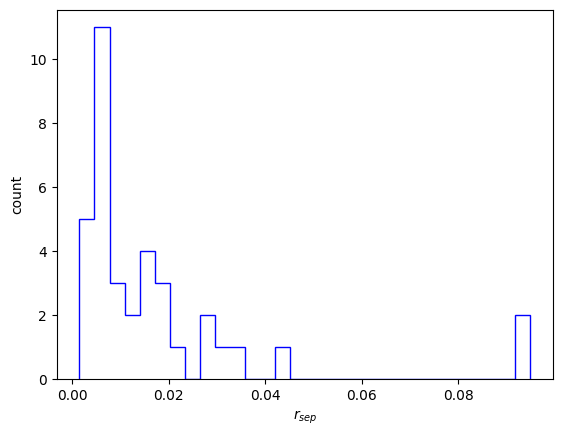

In [38]:
cat1 = SkyCoord(ra=Firm_RA * u.deg, dec=Firm_DEC * u.deg)
cat2 = SkyCoord(ra=TeV_RA_deg * u.deg, dec= TeV_DEC_deg* u.deg)

# Set your threshold (e.g., 5 arcmin)
threshold = 0.1 * u.deg

# Compute pairwise separations
idx_cat2, sep2d, _ = cat1.match_to_catalog_sky(cat2)

# Find which are within threshold
mask = sep2d < threshold

Sep_Matched_TeV_Names = []
Sep_Matched_Firm_Names = []
Separation = []

for i in range(len(cat1)):
    if mask[i]:
        Sep_Matched_TeV_Names.append(TeV_CAT[idx_cat2[i]]['Name'].tolist())
        Sep_Matched_Firm_Names.append(Firm_MeV_Blazar_Catalog[i]['Fermi Counterpart Name'])
        Separation.append(sep2d[i].to(u.deg).value)
        if sep2d[i].to(u.deg).value >= 0.08:
            print(TeV_CAT[idx_cat2[i]]['Name'].tolist(),Firm_MeV_Blazar_Catalog[i]['Fermi Counterpart Name'], sep2d[i].to(u.deg).value)
        
print(Sep_Matched_TeV_Names)
print(len(Sep_Matched_TeV_Names))

print(max(Separation))

bins = 30
plt.hist(Separation, bins,histtype='step',color='blue',label=r'$r_{sep}$')
plt.xlabel(r'$r_{sep}$')
plt.ylabel('count')

plt.savefig(outdir + 'TeV_Firm_Blazars_separation_hist.png', bbox_inches='tight',dpi=300)

In [39]:
TeV_Firm_Matches = Firm_MeV_Blazar_Catalog[[x in Sep_Matched_Firm_Names for x in Firm_MeV_Blazar_Catalog['Fermi Counterpart Name']]]
TeV_Firm_Matches.pprint_all()

 id Match Flag Fermi Counterpart Name   Swift Counterpart Name   Fermi Type Swift Type SED Class      Fermi RA           Fermi DEC      Swift RA Swift DEC    Fermi Redshift    Swift Redshift Fermi Photon Index Fermi Photon Index Err Swift Photon Index Swift Photon Index Err Log Swift Luminosity    Syn Peak Energy         Syn Peak Flux                        Energy                                    Energy Flux                                    Energy Flux Err                
                                                                                                        deg                 deg           deg       deg                                                                                                                                  erg / s                 MeV               MeV / (s cm2)                         MeV                                     MeV / (s cm2)                                    MeV / (s cm2)                 
--- ---------- ---------------------- 

In [40]:
print(Counter(TeV_Firm_Matches['Fermi Type'].tolist()))

Counter({'bll': 20, 'BLL': 6, 'FSRQ': 5, 'bcu': 3, 'fsrq': 2})


In [41]:
TeV_discoverers_all = []
TeV_type_all = []
TeV_Redshift_all = []

for i in range(len(Sep_Matched_TeV_Names)):
    TeV_mask = (TeV_CAT['Name'] == Sep_Matched_TeV_Names[i])
    TeV_source_entry = TeV_CAT[TeV_mask]
    
    TeV_discoverer = TeV_source_entry['Discoverer'].tolist()[0]
    TeV_discoverers_all.append(TeV_discoverer)
    
    TeV_Class = TeV_source_entry['Type'].tolist()[0]
    TeV_type_all.append(TeV_Class)
    
    TeV_Redshift = TeV_source_entry['Distance'].tolist()[0]
    if TeV_Redshift != None and TeV_Redshift != 'z = null':
        TeV_Redshift = float(TeV_Redshift.split('=')[1].strip())
        TeV_Redshift_all.append(TeV_Redshift)
    else:
        TeV_Redshift_all.append(None)
        
print(Counter(TeV_type_all))
print(Counter(TeV_discoverers_all))

TeV_Match_Table = Table([Sep_Matched_TeV_Names, Sep_Matched_Firm_Names,TeV_type_all, TeV_Redshift_all, Separation, TeV_discoverers_all], names=['TeV_assoc_Name', 'Fermi_assoc_Name','TeV_Type', 'Redshift','sep', 'Discoverer'])
TeV_Match_Table.pprint_all()

Counter({'HBL': 24, 'FSRQ': 6, 'IBL': 2, 'FRI': 1, 'LBL': 1, 'UNID': 1, 'Blazar': 1})
Counter({'MAGIC': 11, 'H.E.S.S.': 11, 'VERITAS': 8, 'Whipple': 4, 'Telescope Array': 1, 'Crimea': 1})
 TeV_assoc_Name   Fermi_assoc_Name  TeV_Type  Redshift           sep             Discoverer  
--------------- ------------------- -------- ---------- --------------------- ---------------
   1ES 0033+595        1ES 0033+595      HBL      0.467   0.09243395462766013           MAGIC
  RGB J0136+391         B3 0133+388      HBL       None  0.005341516389595452           MAGIC
   TXS 0210+515        TXS 0210+515      HBL      0.049  0.015446990635257025           MAGIC
   1ES 0229+200        1ES 0229+200      HBL     0.1396  0.044007652421104854        H.E.S.S.
   1ES 0347-121        1ES 0347-121      HBL      0.188   0.01863130104748675        H.E.S.S.
   1ES 0502+675        1ES 0502+675      HBL       0.34   0.00447305666264756         VERITAS
   PKS 0548-322        PKS 0548-322      FRI      0.069   0.

In [42]:
TeV_Blazar_mask = [x in ['HBL', 'IBL','FSRQ','Blazar','BL Lac (class unclear)','LBL'] for x in TeV_CAT['Type'].tolist()]
TeV_Blazars = TeV_CAT[TeV_Blazar_mask]

print(len(TeV_Blazars))
TeV_Blazars.pprint_all()

84
   TeV Name            Name               RA           DEC               Type             Discoverer     Date     Distance        Catalog    
------------- --------------------- ------------- ------------- ---------------------- --------------- ------- -------------- ---------------
TeV J0013-188 SHBL J001355.9-185406    00 13 52.0     -18 53 29                    HBL        H.E.S.S. 2010.11      z = 0.095 Default Catalog
TeV J0033-193        KUV 00311-1938      00 33 36     -19 21 00                    HBL        H.E.S.S. 2012.07             -- Default Catalog
TeV J0035+598          1ES 0033+595    00 35 16.8   +59 47 24.0                    HBL           MAGIC  2011.1      z = 0.467 Default Catalog
TeV J0112+227            S2 0109+22    01 12 05.8     +22 44 39                    IBL           MAGIC 2015.07             -- Default Catalog
TeV J0136+391         RGB J0136+391    01 36 32.5     +39 06 00                    HBL           MAGIC 2012.07             -- Newly Announced
TeV

In [43]:
TeV_Match_mask = [x in Fermi_Name_Firm for x in TeV_CAT_Names]
TeV_Matched_Sources = TeV_CAT[TeV_Match_mask]

Name_TeV_Matched = TeV_Matched_Sources['Name'].tolist()

print(len(TeV_Matched_Sources))
TeV_Matched_Sources.pprint_all()

23
   TeV Name         Name            RA           DEC       Type     Discoverer     Date   Distance      Catalog    
------------- --------------- ------------- ------------- ------ --------------- ------- ---------- ---------------
TeV J0035+598    1ES 0033+595    00 35 16.8   +59 47 24.0    HBL           MAGIC  2011.1  z = 0.467 Default Catalog
TeV J0214+517    TXS 0210+515    02 14 17.9     +51 44 52    HBL           MAGIC 2019.01  z = 0.049 Default Catalog
TeV J0232+202    1ES 0229+200    02 32 53.2     +20 16 21    HBL        H.E.S.S. 2006.12 z = 0.1396 Default Catalog
TeV J0349-119    1ES 0347-121    03 49 23.0     -11 58 38    HBL        H.E.S.S. 2007.08  z = 0.188 Default Catalog
TeV J0507+676    1ES 0502+675    05 07 56.2     +67 37 24    HBL         VERITAS 2009.11   z = 0.34 Newly Announced
TeV J0550-322    PKS 0548-322    05 50 38.4   -32 16 12.9    FRI        H.E.S.S. 2007.07  z = 0.069 Default Catalog
TeV J0648+152 RX J0648.7+1516    06 48 45.6     +15 16 12    HBL     

In [44]:
TeV_Not_Name_Matched = [x for x in Sep_Matched_TeV_Names if x not in Name_TeV_Matched]
Firm_Not_Name_Matched = [x for x in Sep_Matched_Firm_Names if x not in Name_TeV_Matched]
print(len(Firm_Not_Name_Matched))

for i in range(len(TeV_Not_Name_Matched)):
    print(TeV_Not_Name_Matched[i], Firm_Not_Name_Matched[i])

13
RGB J0136+391 B3 0133+388
RGB J0710+591 1H 0658+595
S5 0716+714 S5 0716+71
PGC 2402248 NVSS J073326+515355
PKS 0736+017 PKS 0736+01
Markarian 421 Mkn 421
TON 0599 Ton 599
1ES 1218+304 PG 1218+304
Markarian 501 Mkn 501
HESS J1943+213 MG2 J194359+2118
VER J2016+371 MG2 J201534+3710
BL Lacertae BL Lac
RBS 1366 1E 1415.6+2557


In [45]:
Yeps = [('BL Lacertae', 'BL Lac'), ('Markarian 501', 'Mkn 501'), ('Markarian 421', 'Mkn 421'), ('TON 0599', 'Ton 599'), ('S5 0716+714', 'S5 0716+71'), ('PKS 0736+017', 'PKS 0736+01'), ('1ES 1218+304', 'PG 1218+304'), ('RGB J0136+391', 'B3 0133+388'), ('RGB J0710+591', '1H 0658+595'), ('PGC 2402248', 'NVSS J073326+515355'), ('RBS 1366', '1E 1415.6+2557')]
Maybes = [('HESS J1943+213' 'MG2 J194359+2118')]

In [46]:
print([x for x in Name_TeV_Matched if x not in Sep_Matched_TeV_Names])

Firm_Entry = Firm_MeV_Blazar_Catalog[Firm_MeV_Blazar_Catalog['Fermi Counterpart Name'] == '1ES 0033+595']

Firm_Entry_RA = Firm_Entry['Fermi RA'].tolist()[0]
Firm_Entry_DEC = Firm_Entry['Fermi DEC'].tolist()[0]

TeV_Entry = TeV_CAT[TeV_CAT['Name'] == '1ES 0033+595']
TeV_Entry_RA = Angle(TeV_Entry['RA'].tolist()[0], unit=u.hourangle).degree
TeV_Entry_DEC = Angle(TeV_Entry['DEC'].tolist()[0], unit=u.deg).degree

coord1 = SkyCoord(ra=Firm_Entry_RA * u.deg, dec=Firm_Entry_DEC * u.deg)
coord2 = SkyCoord(ra=TeV_Entry_RA * u.deg, dec=TeV_Entry_DEC * u.deg)

print(coord1.separation(coord2).deg)

[]
0.09243395462766034
